1.   AP23110010139 - Poojitha Gangula
1.   AP23110010106 - Rushi Mahidhar Nayudu
2.   AP23110010097 - Veeraiah Vericherla
1.   AP23110010143 - Vijay Raj Kurella
2.   AP23110010112 - SriRam Nimmalapudi

In [ ]:
from google.colab import files
uploaded = files.upload()
import zipfile

# Get uploaded file name
zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('/content/')

import os
os.listdir('/content/')

import pandas as pd
df = pd.read_csv('train.csv')
df.head()


Saving store-sales-time-series-forecasting.zip to store-sales-time-series-forecasting (5).zip


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [ ]:
!pip install -q xgboost prophet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import xgboost as xgb

In [ ]:
# Load (use train.csv from the dataset)
df = pd.read_csv('train.csv')

# Keep it simple: one store & one item family (reduce complexity)
df = df[(df['store_nbr'] == 1) & (df['family'] == 'GROCERY I')]

# Convert date
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# Rename for consistency
df.rename(columns={'date':'Date','sales':'Sales'}, inplace=True)

df.head()

,id,Date,store_nbr,family,Sales,onpromotion
12,12,2013-01-01,1,GROCERY I,0.0,0
1794,1794,2013-01-02,1,GROCERY I,2652.0,0
3576,3576,2013-01-03,1,GROCERY I,2121.0,0
5358,5358,2013-01-04,1,GROCERY I,2056.0,0
7140,7140,2013-01-05,1,GROCERY I,2216.0,0


In [ ]:
df['dayofweek'] = df['Date'].dt.dayofweek
df['month'] = df['Date'].dt.month
df['year'] = df['Date'].dt.year

# Lag features
df['lag_1'] = df['Sales'].shift(1)
df['lag_7'] = df['Sales'].shift(7)

# Rolling mean (optional but useful)
df['rolling_mean_7'] = df['Sales'].rolling(7).mean()

df = df.dropna()

In [ ]:
train = df[df['Date'] < '2017-01-01']
test = df[df['Date'] >= '2017-01-01']

features = ['dayofweek','month','year','lag_1','lag_7','rolling_mean_7']

X_train = train[features]
y_train = train['Sales']

X_test = test[features]
y_test = test['Sales']

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [ ]:
xg = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1)
xg.fit(X_train, y_train)
xgb_pred = xg.predict(X_test)
def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}")

evaluate("Linear Regression", y_test, lr_pred)
evaluate("Random Forest", y_test, rf_pred)
evaluate("XGBoost", y_test, xgb_pred)

Linear Regression -> MAE: 438.60, RMSE: 576.16
Random Forest -> MAE: 319.04, RMSE: 470.02
XGBoost -> MAE: 326.70, RMSE: 491.33


In [ ]:
final_pred = (lr_pred + rf_pred + xgb_pred) / 3
evaluate("Ensemble", y_test, final_pred)

Ensemble -> MAE: 317.99, RMSE: 457.79


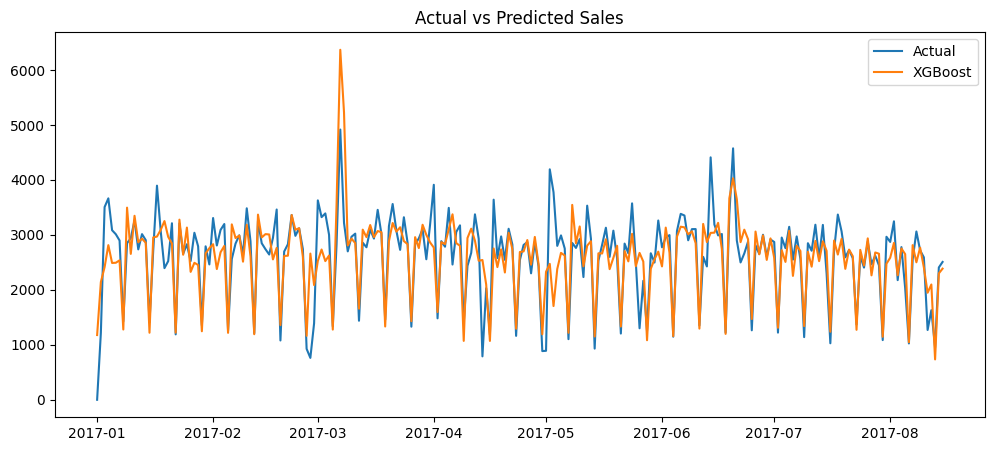

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(test['Date'], y_test, label='Actual')
plt.plot(test['Date'], xgb_pred, label='XGBoost')
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

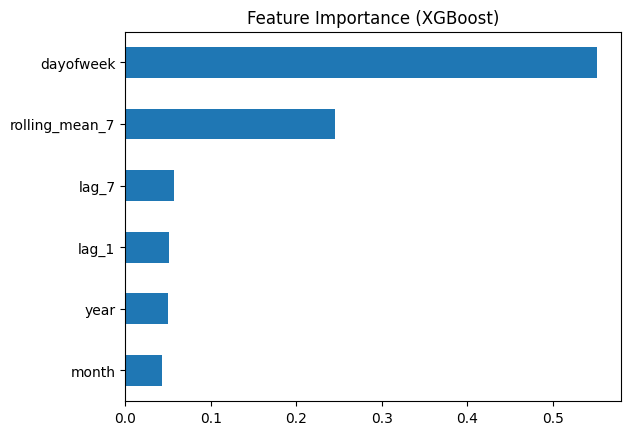

In [ ]:
importance = pd.Series(xg.feature_importances_, index=features)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance (XGBoost)")
plt.show()

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


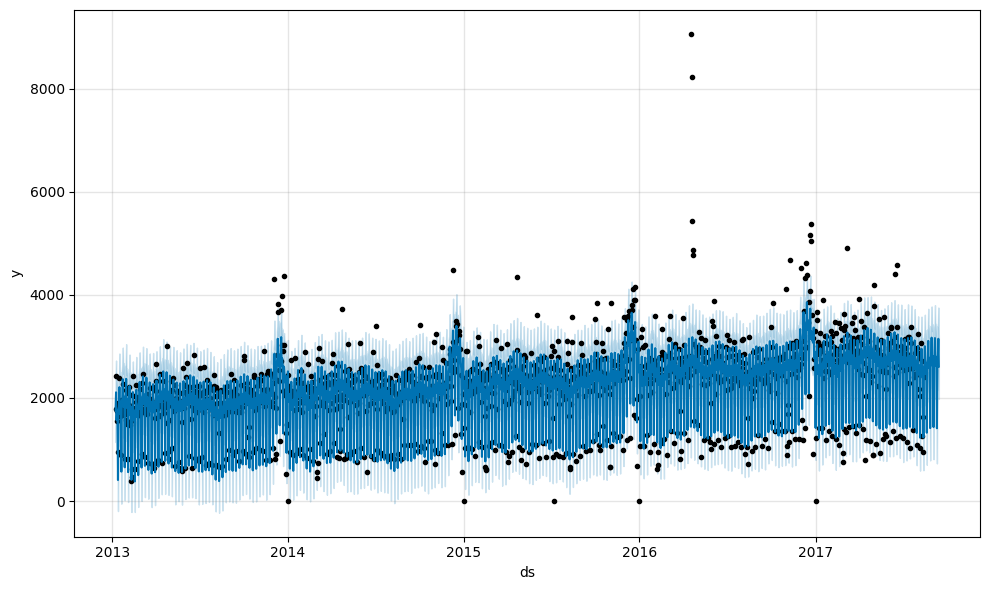

In [ ]:
from prophet import Prophet

prophet_df = df[['Date','Sales']].rename(columns={'Date':'ds','Sales':'y'})

model = Prophet()
model.fit(prophet_df)

future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

model.plot(forecast)
plt.show()

In [ ]:
import pickle
pickle.dump(xg, open('model.pkl', 'wb'))
from google.colab import files
files.download('model.pkl')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

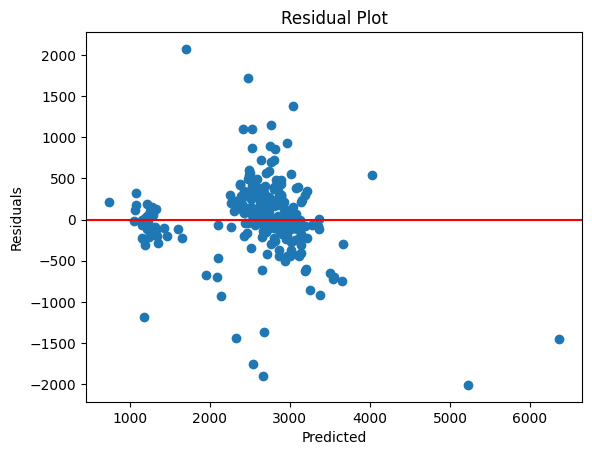

In [ ]:
#Residual Plot
residuals = y_test - xgb_pred

plt.scatter(xgb_pred, residuals)
plt.axhline(y=0, color='r')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

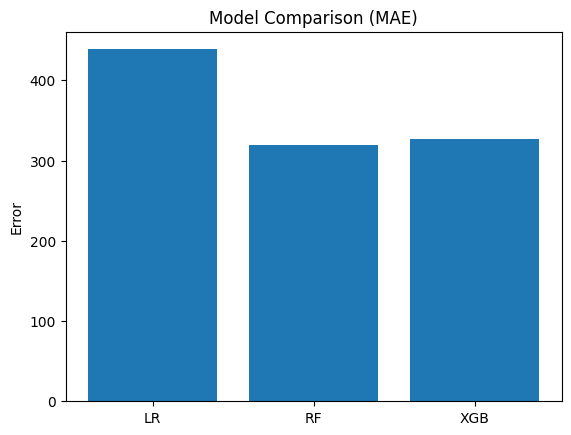

In [ ]:
#Model Comparission Bar Graphs
models = ['LR', 'RF', 'XGB']
mae = [
    mean_absolute_error(y_test, lr_pred),
    mean_absolute_error(y_test, rf_pred),
    mean_absolute_error(y_test, xgb_pred)
]

plt.bar(models, mae)
plt.title("Model Comparison (MAE)")
plt.ylabel("Error")
plt.show()

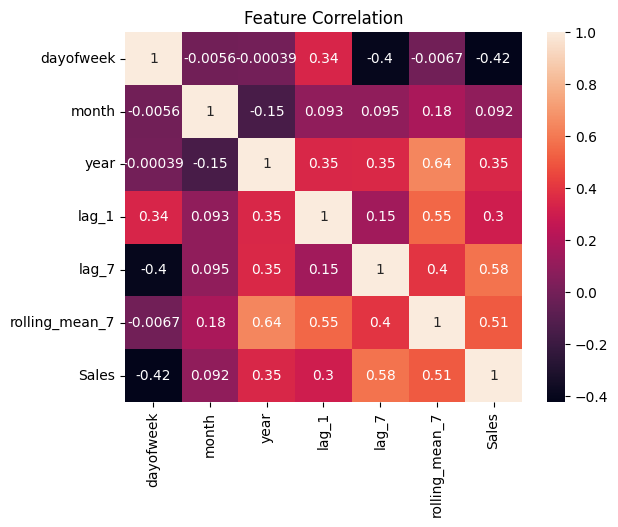

In [ ]:
#Correlation Heatmap
import seaborn as sns

sns.heatmap(df[features + ['Sales']].corr(), annot=True)
plt.title("Feature Correlation")
plt.show()